# Concordance Field Comparison: anchors vs PINN, before and after head

Four columns, one row per band (Rubin `ugrizy` then NISP `YJH`):

1. **raw anchors:** fit-free binned median `|offset|` from `anchors.npz` (`_raw` field). What the data actually says before any solver.
2. **PINN raw:** physics-informed neural field on the same raw offsets.
3. **head-resid anchors:** fit-free binned median of `_head_resid` — what's left at each anchor after the latent-position head corrects it.
4. **PINN after head:** PINN on those head residuals.

Each panel has its own color scale (`vmin=0`, `vmax=p98`) with its own colorbar, so the dynamic range on each map is visible. Compare shapes across a row, not intensities.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from astropy.io import fits
from astropy.table import Table

plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "io").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
CKPT = REPO_ROOT / "models/checkpoints/latent_position_v8_no_psf"
OUT_PNG = REPO_ROOT / "io" / "concordance_3way.png"

SOLVERS = [
    ("NN raw",          CKPT / "concordance_nn_raw_v2_fixed.fits"),
    ("PINN raw",        CKPT / "concordance_pinn_raw_fixed.fits"),
    ("PINN after head", CKPT / "concordance_pinn_head_resid_fixed.fits"),
]

# Coverage is min distance to the nearest training anchor in the FITS' DUNIT
# (currently arcsec for these direct field solvers). Keep the comparison unmasked
# by default; set e.g. COVERAGE_MAX = 100.0 to hide extrapolated regions.
COVERAGE_MAX = None
COVERAGE_CONTOUR = None  # set e.g. 100.0 to draw a coverage boundary

MAS = 1000.0

for label, p in SOLVERS:
    if not p.exists():
        print(f"  WARNING {label}: {p.name} NOT FOUND - run the solver first")
    else:
        print(f"  OK {label}: {p.name}")


  OK NN raw: concordance_nn_raw_v2_fixed.fits
  OK PINN raw: concordance_pinn_raw_fixed.fits
  OK PINN after head: concordance_pinn_head_resid_fixed.fits


In [2]:
def load_grouped(fits_path: Path):
    """Load a concordance FITS and group extensions by band.

    Supports both per-band coverage HDUs (``BAND.COV``) and the newer shared
    ``COVERAGE`` HDU written once for all bands.
    """
    if not fits_path.exists():
        return {}

    with fits.open(fits_path) as hdul:
        grouped = {}
        shared_cov = None
        for idx, hdu in enumerate(hdul):
            if idx == 0 or hdu.data is None or not hdu.name:
                continue

            name = hdu.name.upper()
            if name == "COVERAGE":
                shared_cov = np.array(hdu.data, dtype=float)
                continue

            if "." not in name:
                continue

            prefix, field = name.rsplit(".", 1)
            grouped.setdefault(prefix, {})[field] = np.array(hdu.data, dtype=float)

    grouped = {k: v for k, v in grouped.items() if {"DRA", "DDE"}.issubset(v)}
    if shared_cov is not None:
        for fields in grouped.values():
            fields.setdefault("COV", shared_cov)
    return grouped


def finite_values(arr):
    vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
    return vals[np.isfinite(vals)]


def offset_mag(fields, mask_by_coverage: bool = False):
    """Return |offset| in mas, optionally masking low-coverage regions."""
    mag = np.hypot(fields["DRA"], fields["DDE"]) * MAS
    mag = np.ma.masked_invalid(mag)

    cov = fields.get("COV")
    if mask_by_coverage and COVERAGE_MAX is not None and cov is not None:
        if cov.shape != mag.shape:
            print(f"WARNING coverage shape {cov.shape} does not match field shape {mag.shape}; ignoring")
        else:
            mag = np.ma.masked_where((~np.isfinite(cov)) | (cov > COVERAGE_MAX), mag)
    return mag


solver_data = {}
for label, path in SOLVERS:
    data = load_grouped(path)
    if data:
        solver_data[label] = data

if not solver_data:
    raise FileNotFoundError(f"No concordance FITS files found under {CKPT}")

# Use bands present in every loaded solver.
preferred = ["NISP_H", "NISP_J", "NISP_Y", "U", "G", "R", "I", "Z", "Y"]
common_bands = set.intersection(*(set(data.keys()) for data in solver_data.values()))
BANDS = [b for b in preferred if b in common_bands]
AVAILABLE_SOLVERS = [(label, path) for label, path in SOLVERS if label in solver_data]
print(f"Common bands: {BANDS}")

# Summary table. Values are over the plotted field unless COVERAGE_MAX is enabled.
rows = []
for name in BANDS:
    row = [name]
    for label, _ in AVAILABLE_SOLVERS:
        vals = finite_values(offset_mag(solver_data[label][name], mask_by_coverage=True))
        row.extend([f"{np.nanmedian(vals):.1f}", f"{np.nanpercentile(vals, 95):.1f}"])
    rows.append(tuple(row))

col_names = ["Band"]
for label, _ in AVAILABLE_SOLVERS:
    col_names += [f"{label} med", f"{label} p95"]
display(Table(rows=rows, names=col_names))


Common bands: ['NISP_H', 'NISP_J', 'NISP_Y', 'U', 'G', 'R', 'I', 'Z', 'Y']


Band,NN raw med,NN raw p95,PINN raw med,PINN raw p95,PINN after head med,PINN after head p95
str6,str3,str4,str3,str4,str3,str3
NISP_H,5.7,11.9,7.3,13.1,0.9,2.2
NISP_J,7.2,10.6,7.2,13.7,0.9,2.3
NISP_Y,7.4,9.1,7.3,13.7,0.9,2.0
U,5.9,9.7,9.3,16.8,1.2,3.7
G,4.3,8.4,5.3,12.4,0.8,3.1
R,3.3,6.9,5.1,9.9,0.9,3.4
I,3.9,6.0,5.3,9.6,1.0,2.3
Z,3.8,6.5,5.4,11.2,1.1,3.1
Y,3.2,5.3,6.0,12.9,1.8,4.6


Saved /home/shemmati/Work/Projects/JAISP/io/concordance_3way.png


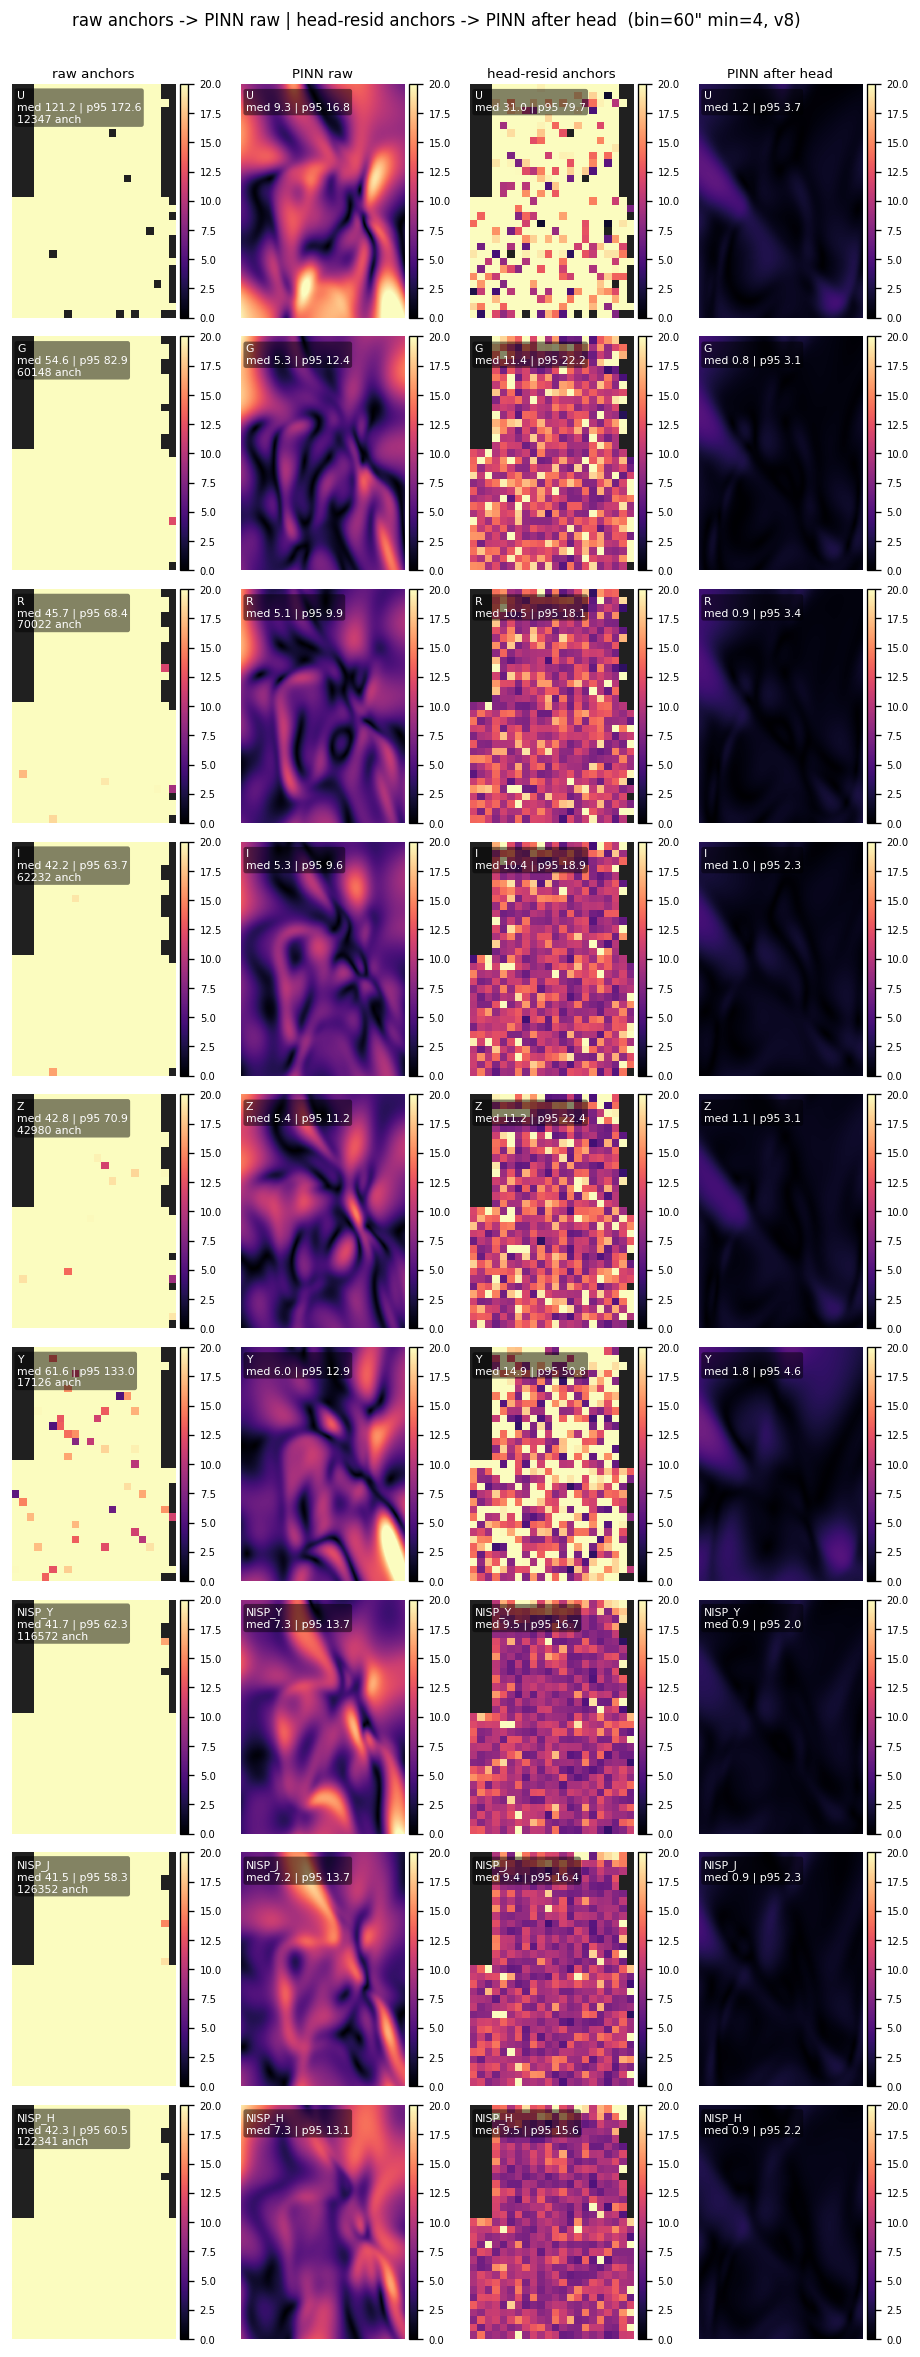

In [4]:
# -- Four-column comparison: raw anchors | PINN raw | head-resid anchors | PINN after head
# Each panel has its own color scale (vmin=0, vmax=per-panel p98) and its own compact colorbar.

from scipy.stats import binned_statistic_2d
from astropy.wcs import WCS
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl

ANCHORS_PATH = CKPT / "anchors.npz"
BIN_ARCSEC = 60.0    # raw-anchor bin size (arcsec)
MIN_COUNT  = 4       # mask bins with fewer anchors than this

# Rubin ugrizy, then NISP YJH.
BAND_ORDER_NEW = ["U", "G", "R", "I", "Z", "Y", "NISP_Y", "NISP_J", "NISP_H"]
BAND_KEYS = {
    "U": "u", "G": "g", "R": "r", "I": "i", "Z": "z", "Y": "y",
    "NISP_Y": "nisp_Y", "NISP_J": "nisp_J", "NISP_H": "nisp_H",
}

pinn_raw  = solver_data.get("PINN raw", {})
pinn_head = solver_data.get("PINN after head", {})
if not pinn_raw or not pinn_head:
    raise FileNotFoundError("Need both PINN raw and PINN after head solver FITS")

bands_plot = [b for b in BAND_ORDER_NEW if b in pinn_raw and b in pinn_head]
if not bands_plot:
    raise ValueError("No common bands between PINN solvers")

# Use the first PINN FITS WCS so anchor bins share the sky frame with the fits.
pinn_path = next(p for lbl, p in SOLVERS if lbl == "PINN raw" and p.exists())
with fits.open(pinn_path) as hdul:
    img_hdr   = next(h.header for h in hdul[1:] if h.data is not None and h.data.ndim == 2)
    img_shape = next(h.data for h in hdul[1:] if h.data is not None and h.data.ndim == 2).shape
wcs_out = WCS(img_hdr)
image_h_pix, image_w_pix = img_shape

bin_px  = max(1, int(round(BIN_ARCSEC / float(img_hdr.get("DSTEP", 1.0)))))
x_edges = np.arange(0, image_w_pix + bin_px, bin_px)
y_edges = np.arange(0, image_h_pix + bin_px, bin_px)

anchors_npz = np.load(ANCHORS_PATH)

def bin_anchors(band_disp, field_key):
    key = BAND_KEYS[band_disp]
    ra  = anchors_npz[f"{key}_ra"]
    dec = anchors_npz[f"{key}_dec"]
    off = anchors_npz[f"{key}_{field_key}"]
    mag = np.hypot(off[:, 0], off[:, 1]) * MAS
    px, py = wcs_out.all_world2pix(ra, dec, 0)
    med, _, _, _ = binned_statistic_2d(px, py, mag, statistic="median", bins=[x_edges, y_edges])
    cnt, _, _, _ = binned_statistic_2d(px, py, mag, statistic="count",  bins=[x_edges, y_edges])
    med = np.where(cnt >= MIN_COUNT, med, np.nan)
    return np.ma.masked_invalid(med.T), int(len(ra))

raw_maps  = {b: bin_anchors(b, "raw")        for b in bands_plot}
head_maps = {b: bin_anchors(b, "head_resid") for b in bands_plot}

# Colormap with a dark "bad" color so masked (low-count) bins read as empty.
cmap = mpl.colormaps["magma"].copy()
cmap.set_bad("#202020")

def robust_vmax(arr):
    v = finite_values(arr)
    if v.size == 0:
        return 1.0
    return float(np.nanpercentile(v, 98.0))

# ── Figure --------------------------------------------------------------
ncols = 4
nrows = len(bands_plot)
sample = pinn_raw[bands_plot[0]]["DRA"]
img_h, img_w = sample.shape
panel_h = 2.15
panel_w = panel_h * img_w / img_h
# Each panel needs ~15% extra width for its own colorbar.
fig_w = panel_w * ncols * 1.18 + 0.4
fig_h = panel_h * nrows + 0.75

fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h), squeeze=False)
col_labels = ["raw anchors",
              "PINN raw",
              "head-resid anchors",
              "PINN after head"]

for row, name in enumerate(bands_plot):
    pinn_raw_mag  = offset_mag(pinn_raw[name],  mask_by_coverage=True)
    pinn_head_mag = offset_mag(pinn_head[name], mask_by_coverage=True)
    raw_bin, n_anch = raw_maps[name]
    head_bin, _     = head_maps[name]

    row_panels = [
        (raw_bin,        [0, image_w_pix, 0, image_h_pix]),
        (pinn_raw_mag,   None),
        (head_bin,       [0, image_w_pix, 0, image_h_pix]),
        (pinn_head_mag,  None),
    ]
    for col, (data, extent) in enumerate(row_panels):
        ax = axes[row, col]
        vmax = 20#robust_vmax(data)
        kwargs = dict(cmap=cmap, vmin=0, vmax=vmax, interpolation="nearest")
        if extent is not None:
            kwargs["extent"] = extent
        im = ax.imshow(data, **kwargs)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
        if row == 0:
            ax.set_title(col_labels[col], fontsize=8, pad=4)

        v = finite_values(data)
        med = np.nanmedian(v) if v.size else np.nan
        p95 = np.nanpercentile(v, 95) if v.size else np.nan
        extra = f"\n{n_anch} anch" if col == 0 else ""
        ax.text(
            0.03, 0.97, f"{name}\nmed {med:.1f} | p95 {p95:.1f}{extra}",
            transform=ax.transAxes, va="top", ha="left", fontsize=6.5,
            color="white",
            bbox=dict(boxstyle="round,pad=0.22", facecolor="black", alpha=0.48, edgecolor="none"),
        )

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.04)
        cb = fig.colorbar(im, cax=cax)
        cb.ax.tick_params(labelsize=6)

fig.subplots_adjust(left=0.02, right=0.995, bottom=0.02, top=0.955, hspace=0.08, wspace=0.22)
fig.suptitle(
    f"raw anchors -> PINN raw | head-resid anchors -> PINN after head  "
    f"(bin={BIN_ARCSEC:.0f}\" min={MIN_COUNT}, v8)",
    fontsize=10, y=0.985,
)
plt.savefig(OUT_PNG, dpi=180, bbox_inches="tight")
print(f"Saved {OUT_PNG}")
plt.show()
